# Simulación de un ADC: muestreo, ruido y cuantización

En este trabajo se simula el funcionamiento de un ADC considerando:

- Muestreo de una señal senoidal
- Presencia de ruido aditivo gaussiano
- Cuantización uniforme

Se analiza el efecto de la cantidad de bits y del nivel de ruido sobre la calidad de la señal digitalizada.

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../lib')

from mis_funciones import mi_senoidal

## Parámetros de simulación

Se define una señal senoidal de energía unitaria y una frecuencia compatible con la grilla espectral.

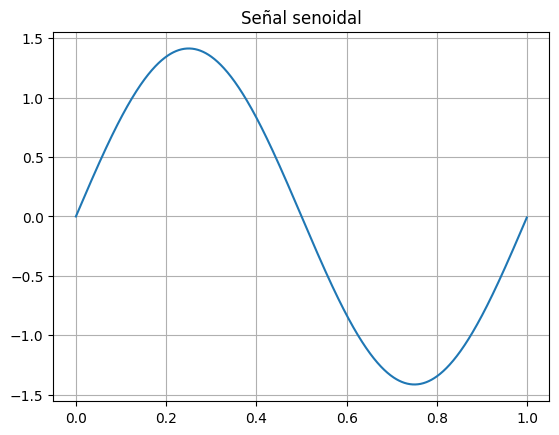

In [3]:
fs = 1000
n = 1000
ts = 1/fs

f0 = fs/n

vmax = np.sqrt(2)  # energía unitaria
dc = 0

tt, xx = mi_senoidal(vmax, dc, f0, n, fs, ts, ph=0)

plt.plot(tt, xx)
plt.title("Señal senoidal")
plt.grid()
plt.show()

## Modelo del ADC

El ADC se modela mediante:

- Cuantización uniforme en el rango ±VF
- Ruido aditivo gaussiano

La potencia del ruido se define como:

Pn = kn · Pq

donde Pq es la potencia del ruido de cuantización.

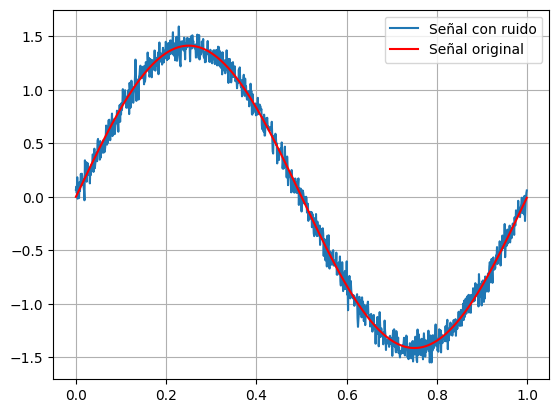

In [4]:
B = 4
Vfs = 2

qq = (2*Vfs)/(2**B)
Pq = qq**2 / 12

kn = 1

Pn = kn * Pq
sigma = np.sqrt(Pn)

ruido = np.random.normal(0, sigma, n)

xxn = xx + ruido

plt.plot(tt, xxn, label='Señal con ruido')
plt.plot(tt, xx, 'r', label='Señal original')
plt.legend()
plt.grid()
plt.show()

## Cuantización y cálculo del SNR

Se cuantiza la señal y se calcula el SNR considerando el error total.

In [5]:
xxq = np.round(xxn/qq)*qq

error = xx - xxq

SNR = 10*np.log10(np.var(xx)/np.var(error))
print(f"SNR: {SNR:.2f} dB")

SNR: 19.43 dB


## Análisis espectral

Se observa el espectro de la señal cuantizada para evaluar el nivel de ruido.

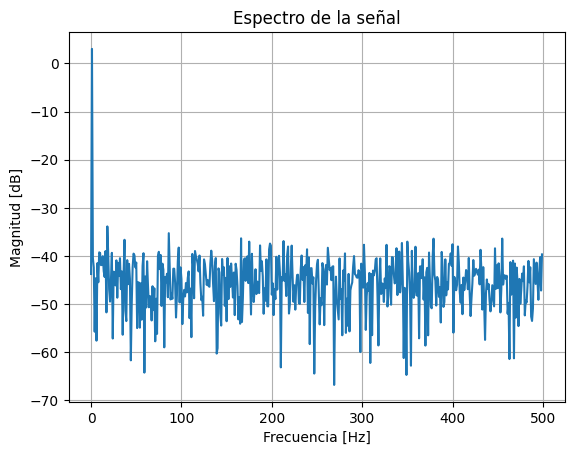

In [6]:
XX = np.fft.fft(xxq)/n
XX = XX[:n//2]

freq = np.fft.fftfreq(n, ts)[:n//2]

XX_db = 20*np.log10(np.abs(XX)*2)

plt.plot(freq, XX_db)
plt.title("Espectro de la señal")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.grid()
plt.show()

## Distribución del error

Se analiza la distribución del error total, que resulta de la suma del ruido analógico y el error de cuantización.

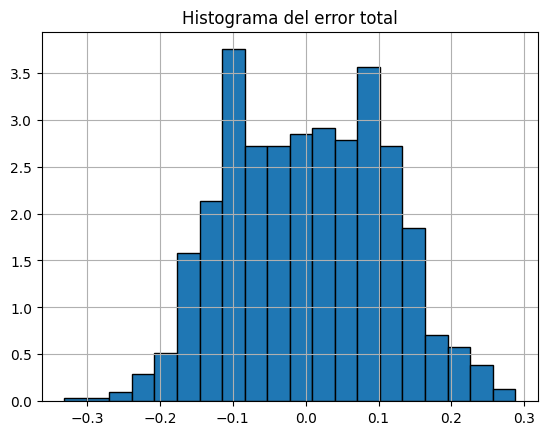

In [7]:
plt.hist(error, bins=20, density=True, edgecolor='black')
plt.title("Histograma del error total")
plt.grid()
plt.show()

## Análisis de las componentes del error

Se separa el error en:

- Ruido analógico (gaussiano)
- Error de cuantización (uniforme)

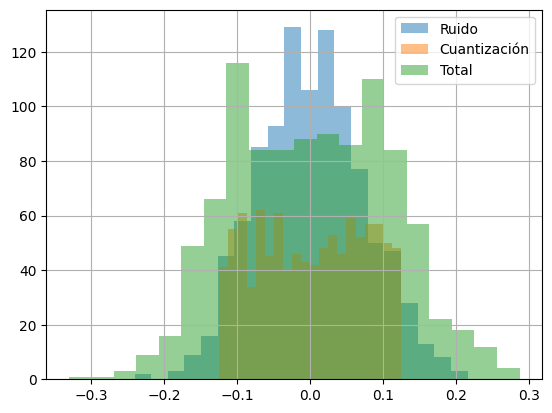

In [8]:
error_ruido = xx - xxn
error_cuant = xxn - xxq

plt.hist(error_ruido, bins=20, alpha=0.5, label='Ruido')
plt.hist(error_cuant, bins=20, alpha=0.5, label='Cuantización')
plt.hist(error, bins=20, alpha=0.5, label='Total')

plt.legend()
plt.grid()
plt.show()

## Comparación con mayor nivel de ruido

Se analiza el caso B=4 y kn=10, donde el ruido analógico domina sobre el de cuantización.

In [9]:
kn = 10

Pn = kn * Pq
sigma = np.sqrt(Pn)

ruido = np.random.normal(0, sigma, n)
xxn_b = xx + ruido

xxq_b = np.round(xxn_b/qq)*qq

error_b = xx - xxq_b

SNR_b = 10*np.log10(np.var(xx)/np.var(error_b))

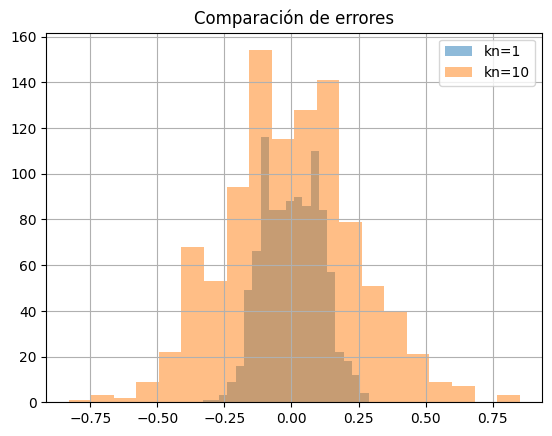

In [10]:
plt.hist(error, bins=20, alpha=0.5, label='kn=1')
plt.hist(error_b, bins=20, alpha=0.5, label='kn=10')
plt.legend()
plt.title("Comparación de errores")
plt.grid()
plt.show()

Al aumentar kn, el ruido analógico domina, lo que produce una distribución más cercana a una gaussiana y una disminución del SNR.

## Relación entre SNR y cantidad de bits

De acuerdo con la teoría (Holton, sección de cuantización), el SNR de un ADC ideal está dado por:

SNR ≈ 6.02 B + 1.76 dB

Esto implica que cada bit adicional incrementa el SNR aproximadamente en 6 dB.

## Aliasing

El aliasing ocurre cuando la frecuencia de la señal supera la frecuencia de Nyquist (fs/2), produciendo una representación incorrecta de la señal.

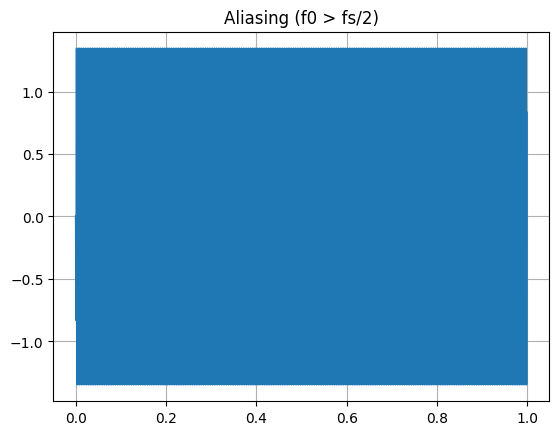

In [11]:
f0 = 600

tt, xx_alias = mi_senoidal(vmax, dc, f0, n, fs, ts)

plt.plot(tt, xx_alias)
plt.title("Aliasing (f0 > fs/2)")
plt.grid()
plt.show()

## Conclusión

En este trabajo se simuló el comportamiento de un ADC considerando el efecto combinado del muestreo, el ruido y la cuantización.

Se observó que el error total depende de la relación entre el ruido analógico y el ruido de cuantización. Cuando ambos son comparables, la distribución del error presenta características mixtas, mientras que cuando uno domina, la distribución tiende a su forma característica.

Además, se verificó que el aumento en la cantidad de bits mejora el SNR, en concordancia con la relación teórica SNR ≈ 6.02B + 1.76 dB.

Finalmente, se evidenció el fenómeno de aliasing, resaltando la importancia de respetar el criterio de Nyquist en sistemas de adquisición de señales.